In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


In [66]:

uploaded = files.upload()
image_paths = list(uploaded.keys())
print("Uploaded files:", image_paths)


Saving office.jpg to office (1).jpg
Uploaded files: ['office (1).jpg']


In [67]:

face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise ValueError("Haar Cascade file could not be loaded.")

print("Haar Cascade loaded successfully.")

Haar Cascade loaded successfully.


In [76]:

def detect_faces(image_path, scaleFactor=1.03, minNeighbors=2):


    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=scaleFactor,
        minNeighbors=minNeighbors,
        minSize=(20, 20)
    )

    output = img_rgb.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 4)

    return img_rgb, gray, output, faces

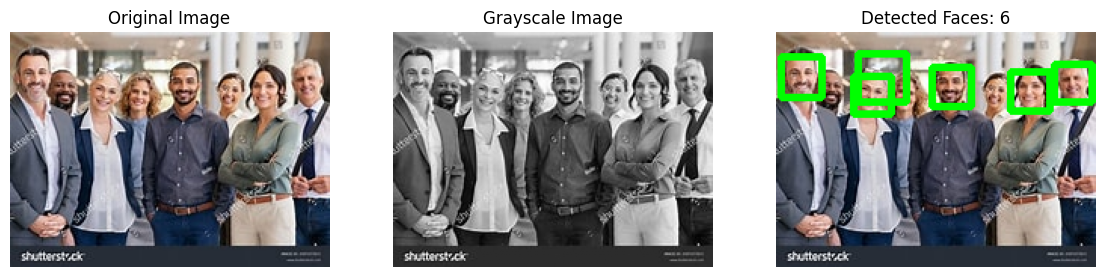

Image: office (1).jpg
Faces detected: 6
----------------------------------------


In [77]:
for image_path in image_paths:
    img_rgb, gray, output, faces = detect_faces(image_path)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(output)
    plt.title(f"Detected Faces: {len(faces)}")
    plt.axis("off")

    plt.show()

    print(f"Image: {image_path}")
    print("Faces detected:", len(faces))
    print("-" * 40)

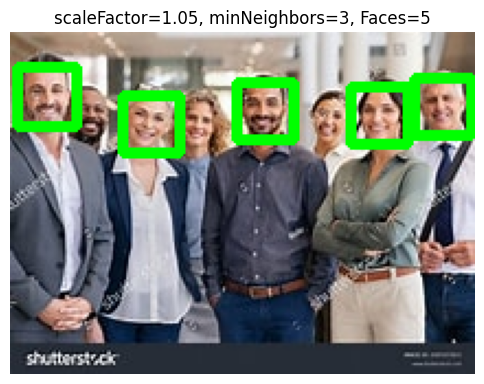

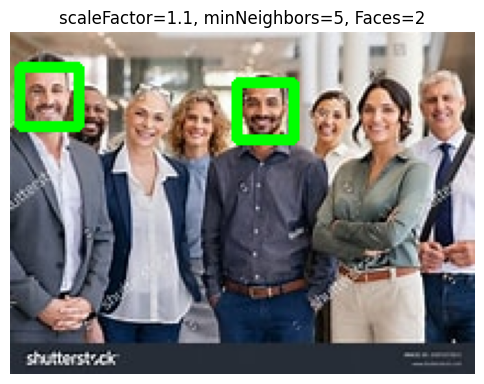

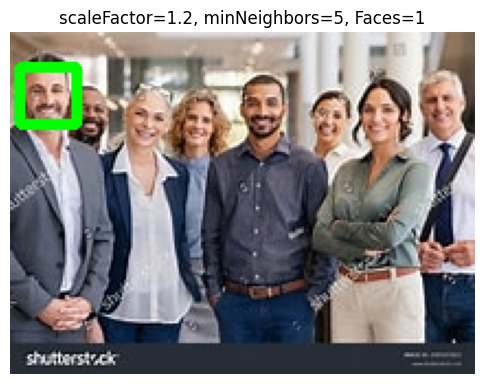

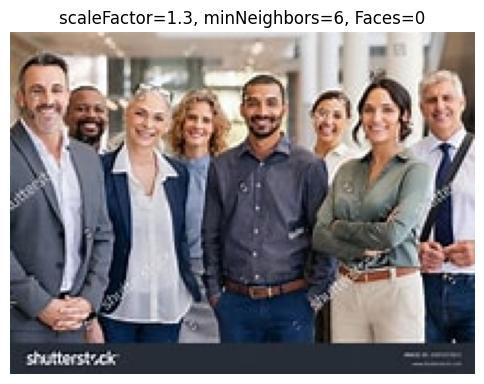

In [78]:
# Select first image for parameter testing
test_image = image_paths[0]

parameter_settings = [
    (1.05, 3),
    (1.1, 5),
    (1.2, 5),
    (1.3, 6)
]

for scaleFactor, minNeighbors in parameter_settings:
    img_rgb, gray, output, faces = detect_faces(
        test_image,
        scaleFactor=scaleFactor,
        minNeighbors=minNeighbors
    )

    plt.figure(figsize=(6,5))
    plt.imshow(output)
    plt.title(f"scaleFactor={scaleFactor}, minNeighbors={minNeighbors}, Faces={len(faces)}")
    plt.axis("off")
    plt.show()